EDA Part 2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/cleaned/customer_churn_cleaned.csv')


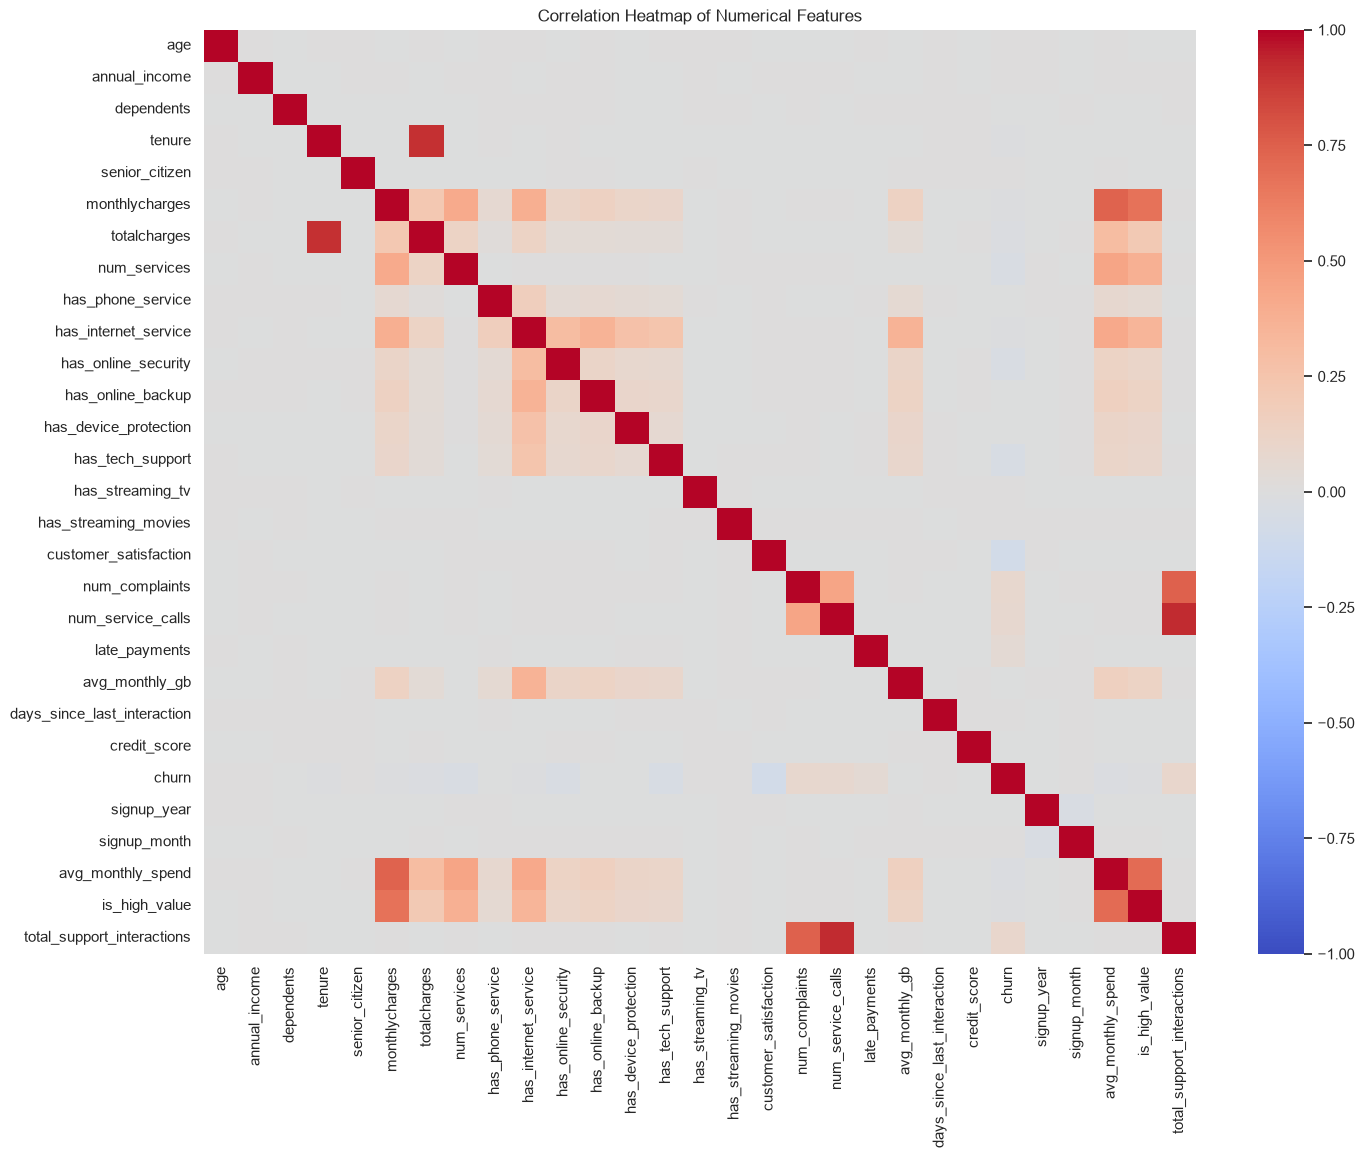

In [3]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()


In [4]:
# Sort correlations with 'churn', dropping 'churn' itself
churn_corr = corr_matrix['churn'].drop('churn').sort_values(ascending=False)
print("Top positive correlations with churn:\n", churn_corr.head(5))
print("\nTop negative correlations with churn:\n", churn_corr.tail(5))


Top positive correlations with churn:
 total_support_interactions    0.090182
num_complaints                0.078632
num_service_calls             0.077284
late_payments                 0.047705
has_streaming_movies          0.001915
Name: churn, dtype: float64

Top negative correlations with churn:
 totalcharges            -0.016501
num_services            -0.033378
has_online_security     -0.034106
has_tech_support        -0.045477
customer_satisfaction   -0.083827
Name: churn, dtype: float64


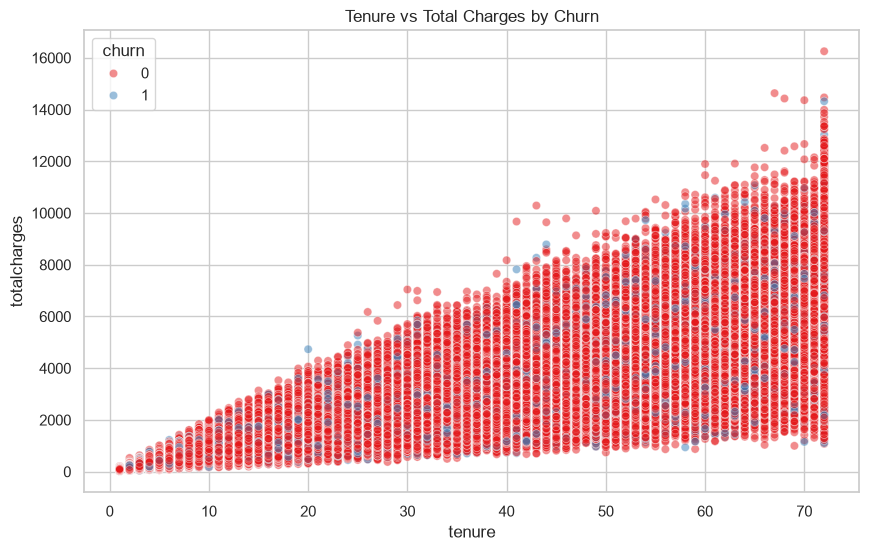

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='totalcharges', hue='churn', alpha=0.5, palette='Set1')
plt.title('Tenure vs Total Charges by Churn')
plt.savefig('../images/tenure_vs_charges.png')
plt.show()


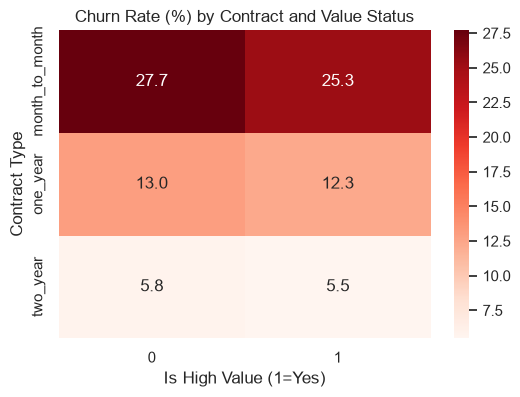

In [6]:
# Create a crosstab showing the mean churn (which equals the churn rate)
segment_churn = pd.crosstab(df['contract'], df['is_high_value'], values=df['churn'], aggfunc='mean') * 100

# Visualize the crosstab as a mini heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(segment_churn, annot=True, fmt=".1f", cmap="Reds")
plt.title('Churn Rate (%) by Contract and Value Status')
plt.ylabel('Contract Type')
plt.xlabel('Is High Value (1=Yes)')
plt.savefig('../images/segment_churn_heatmap.png', bbox_inches='tight')
plt.show()
